# Decision-Model Comparison: Jev, pplx-decider and gpt-6-luna

This notebook compares three decision models as `DecisionTitleAbstractReviewer` backends on the same 11,793 articles
used in `decision_evaluation.ipynb`, with the same criteria and the same questions:

| Model | Maker | Backend used here | Price (input tokens) |
|---|---|---|---|
| **Jev** (`jev-latest`) | TypeSafe | OpenRouter (`~typesafe/jev-latest`) | $0.042 per million |
| **pplx-decider** (`pplx-decider-v1.1-27b`) | Perplexity | OpenRouter (`perplexity/pplx-decider-v1.1-27b`, served by Perplexity) | $0.02 per million |
| **gpt-6-luna** | OpenAI | OpenAI's Decisions API (`SystemOneProvider(backend="openai")`) | $0.10 per million |

All three are compared against the stored v1 LLM decisions (Agent1 `gemini-2.5-flash`, Agent2 `gpt-4o-mini`, and
Agent3 `gpt-4o` on disagreements). Results are cached in `decision_results_*/`, so re-running this notebook does not
call any API again.

These runs use LatteReview 1.4.0, which leaves the workflow's `Review Task ID` line out of the decision model's input.
Jev's numbers therefore differ slightly from `decision_evaluation.ipynb` (1.3.0), which also reflects Jev's small
run-to-run variation on uncertain articles.

## Setting up the notebook

In [1]:
from dotenv import load_dotenv

# Load environment variables from .env file. Adjust the path to the .env file as needed.
load_dotenv(dotenv_path="../.env")

# Enable asyncio in Jupyter
import asyncio
import nest_asyncio

nest_asyncio.apply()

# Add the package to the path (required if you are running this notebook from the evaluation folder)
import sys

sys.path.append("../")

In [2]:
import contextlib
import io
import json
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lattereview.providers import SystemOneProvider
from lattereview.agents import DecisionTitleAbstractReviewer
from lattereview.workflows import ReviewWorkflow
from lattereview.utils import suggest_threshold

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

## Datasets and criteria

The same criteria and loading code as `decision_evaluation.ipynb`.

In [3]:
CUSTOM_CRITERIA = {
    "search1": {
        "inclusion_criteria": {
            1: "The study must involve CT scans. If multiple modalities are involved, CT scans should be among them.",
        },
        "exclusion_criteria": {
            1: "The study must not include PET scans as one of its modalities.",
        },
    },
    "search2": {
        "inclusion_criteria": {
            1: "The study must involve CT scans. If multiple modalities are involved, CT scans should be among them.",
            2: "The study should introduce, develop, or discuss a deep learning-baseed classifier.",
        },
        "exclusion_criteria": {
            1: "The study must not include PET scans as one of its modalities.",
            2: "Studies focusing on cardiovascular organs or lung vasculature must be excluded.",
        },
    },
    "search3": {
        "inclusion_criteria": {
            1: "The study must involve CT scans. If multiple modalities are involved, CT scans should be among them.",
            2: "The study should introduce, develop, or discuss a deep learning-baseed classifier.",
            3: "The clinical application or model in the study must focus on diagnosis.",
        },
        "exclusion_criteria": {
            1: "The study must not include PET scans as one of its modalities.",
            2: "Studies focusing on cardiovascular organs or lung vasculature must be excluded.",
            3: "All studies that did not have an external test set in addition to their internal test set must be excluded.",
        },
    },
}

In [4]:
SYNERGY_CRITERIA = {'Appenzeller-Herzog_2019': {'inclusion_criteria': "-Patients with Wilson's Disease of any age or stage\n"
                                                   '-Study drug has to be one of four established therapies, '
                                                   'namely DPen, trientine, TTM or Zn.\n'
                                                   '-Control could be placebo, no treatment or any other '
                                                   'treatment that does not include the respective study '
                                                   'drug\n'
                                                   '-Concomitant therapies had to be identical in the '
                                                   'compared treatment arms\n'
                                                   '-Combination therapy regimens that include the '
                                                   'respective monotherapy drug are not considered\n'
                                                   '-Prospective or retrospective studies reported\n'
                                                   '-Randomized, non-randomized controlled trials and '
                                                   'comparative observational studies',
                             'exclusion_criteria': '-Animal studies, case reports, case series, '
                                                   'cross-sectional studies, before-after studies, reviews, '
                                                   'letters, abstract-only publications, editorials, '
                                                   'diagnostic or other testing studies and non-controlled '
                                                   'studies'},
 'Donners_2021': {'inclusion_criteria': 'The following inclusion criteria are applied: emicizumab studies '
                                        'providing (1) data on humans, (2) original PK data or modeled PK '
                                        'data or PK/PD relationships, and (3) access to the abstract and the '
                                        'full text in English. In the event of doubt regarding eligibility, '
                                        'the records or articles should be included.',
                  'exclusion_criteria': 'Not specified'},
 'Jeyaraman_2020': {'inclusion_criteria': 'Studies are included if they meet the following PICOS criteria: '
                                          'Population: Patients with knee osteoarthritis Intervention: MSC '
                                          'therapy Comparator: Usual care Outcomes: Visual Analog Score '
                                          '(VAS) for Pain, Western Ontario McMaster Universities '
                                          'Osteoarthritis Index (WOMAC), Lysholm Knee Scale (Lysholm), '
                                          'Whole-Organ Magnetic Resonance Imaging Score (WORMS), Knee '
                                          'Osteoarthritis Outcome Score (KOOS), and adverse events Study '
                                          'Design: Randomized controlled trials',
                    'exclusion_criteria': 'Trials are excluded if they had the following characteristics: 1. '
                                          'Observational studies and interventional studies without a '
                                          'comparator group 2. Animal studies involving stem cell therapy '
                                          'for knee osteoarthritis models 3. Review'},
 'Meijboom_2021': {'inclusion_criteria': 'Articles are included if they meet the following criteria: (1) '
                                         'study involved transitioning from a TNF-alpha inhibitor (including '
                                         'etanercept, infliximab, and adalimumab) originator to a '
                                         'biosimilar, (2) the number of patients who retransitioned is '
                                         'reported or can be calculated, (3) the article is an original '
                                         'research article published in a peer-reviewed journal, (4) the '
                                         'article included baseline characteristics of the patients who '
                                         'transitioned, (5) the article is written in English. Transitioning '
                                         'is defined as patients in whom the biosimilar was introduced after '
                                         'the originator, without treatment with other drugs in between. '
                                         'Retransitioning is defined as restarting the originator directly '
                                         'after discontinuing a biosimilar, without treatment with other '
                                         'drugs in between. In summary, transitioning is defined as '
                                         'switching from the originator to a biosimilar; retransitioning is '
                                         'defined as switching from the originator to a biosimilar and back '
                                         'to the originator. Both transitioning and retransitioning involve '
                                         'changes with the same active biological substance.',
                   'exclusion_criteria': 'Not specified'},
 'Muthu_2021': {'inclusion_criteria': 'To be included, a study should meet the following criteria: 1. The '
                                      'study should be an RCT with 1:1 parallel two-arm design. 2. The study '
                                      'must be related to spine surgery involving preoperative or '
                                      'intraoperative or postoperative variables. 3. The study must have a '
                                      'dichotomous primary or secondary outcome.',
                'exclusion_criteria': '1. Studies not involving human subjects. 2. Studies with continuous '
                                      'variable outcomes like pain scores, Oswestry Disability Index scores, '
                                      'time to union without predefined clinical success criteria. 3. '
                                      'Studies that did not report a statistically significant primary or '
                                      'secondary outcome measure.'},
 'Oud_2018': {'inclusion_criteria': 'Randomized controlled trials (RCT)s on four specialized psychotherapies '
                                    '(DBT: dialectic behavior therapy, MBT: mentalization-based treatment, '
                                    'TFP: transference-focused therapy and ST: schema therapy) for adults '
                                    '(18 years and older) with Borderline personality disorder (BPD), which '
                                    'includes an individual psychotherapy component and had a duration of 16 '
                                    'weeks or more. Eligible comparison groups are other protocolized and '
                                    'specialized psychotherapies, or control groups, for example, treatment '
                                    'as usual (TAU), waiting list, attention control or community treatment '
                                    'by experts (CTBE).',
              'exclusion_criteria': 'Studies are excluded with a cut-off of <66% of the participants having '
                                    'BPD, unless disaggregated data are provided. Studies are excluded that '
                                    'tested incomplete versions of specialized treatment, for example, '
                                    'studies that investigated only skills training instead of the full DBT '
                                    'program.'}}

In [5]:
DATASETS = ["search1", "search2", "search3"] + sorted(SYNERGY_CRITERIA)


def llm_score(row):
    """The stored v1 LLM decision, computed as in synergy_evaluation.ipynb: Agent3 if it reviewed, else the mean."""
    if "round-B_Agent3_output" in row and not pd.isna(row["round-B_Agent3_evaluation"]):
        return int(row["round-B_Agent3_evaluation"])
    return (int(row["round-A_Agent1_evaluation"]) + int(row["round-A_Agent2_evaluation"])) / 2


def load_dataset(name):
    """Return (data, inclusion_criteria, exclusion_criteria) with `label` and `llm_score` columns."""
    if name in CUSTOM_CRITERIA:
        df = pd.read_csv(f"custom_data/{name}_reviewed.csv", index_col=0)
        df["label"] = df[name].astype(int)
        criteria = CUSTOM_CRITERIA[name]
    else:
        df = pd.read_csv(f"synergy_data/{name}_reviewed.csv", index_col=0)
        df["label"] = df["label_included"].astype(int)
        criteria = SYNERGY_CRITERIA[name]
    df["llm_score"] = df.apply(llm_score, axis=1)
    exclusion = criteria["exclusion_criteria"]
    if isinstance(exclusion, str) and exclusion.strip().lower() == "not specified":
        exclusion = ""
    return df, criteria["inclusion_criteria"], exclusion


for name in DATASETS:
    df, _, _ = load_dataset(name)
    print(f"{name:25s} {len(df):5d} articles, {df['label'].sum():4d} included ({df['label'].mean():.1%})")

search1                     978 articles,  697 included (71.3%)
search2                     978 articles,  367 included (37.5%)
search3                     978 articles,   55 included (5.6%)
Appenzeller-Herzog_2019    2873 articles,   26 included (0.9%)
Donners_2021                258 articles,   15 included (5.8%)
Jeyaraman_2020             1175 articles,   96 included (8.2%)
Meijboom_2021               882 articles,   37 included (4.2%)
Muthu_2021                 2719 articles,  336 included (12.4%)
Oud_2018                    952 articles,   20 included (2.1%)


## Running the models

One `DecisionTitleAbstractReviewer` per model and dataset, built exactly as in `decision_evaluation.ipynb`: each
article is one request carrying the 5-level evaluation score, the overall include question, and one question per
criterion. Each model runs once and is cached in its own folder.

In [6]:
MODELS = {
    "Jev": {
        "results_dir": "decision_results_jev",
        "provider": lambda: SystemOneProvider(backend="openrouter"),  # ~typesafe/jev-latest
    },
    "pplx-decider": {
        "results_dir": "decision_results_pplx_decider",
        "provider": lambda: SystemOneProvider(backend="openrouter", model="perplexity/pplx-decider-v1.1-27b"),
    },
    "gpt-6-luna": {
        "results_dir": "decision_results_gpt_6_luna",
        "provider": lambda: SystemOneProvider(backend="openai"),
        "max_concurrent_requests": 16,  # OpenAI allows 30,000 requests per minute
    },
}


async def run_model(model, name):
    df, inclusion, exclusion = load_dataset(name)
    provider = MODELS[model]["provider"]()
    reviewer = DecisionTitleAbstractReviewer(
        provider=provider,
        name="Decision",
        inclusion_criteria=inclusion,
        exclusion_criteria=exclusion,
        max_concurrent_requests=MODELS[model].get("max_concurrent_requests", 8),
        verbose=False,
    )
    workflow = ReviewWorkflow(
        workflow_schema=[{"round": "A", "reviewers": [reviewer], "text_inputs": ["title", "abstract"]}],
        verbose=False,
    )
    start = time.time()
    reviewed = await workflow(df)
    seconds = time.time() - start
    await provider.aclose()

    outputs = reviewed["round-A_Decision_output"]
    results = pd.DataFrame(
        {
            "label": reviewed["label"],
            "llm_score": reviewed["llm_score"],
            "evaluation": reviewed["round-A_Decision_evaluation"],
            "include_probability": reviewed["round-A_Decision_include_probability"],
            "confidence": reviewed["round-A_Decision_confidence"],
            "answers": outputs.apply(lambda output: json.dumps(output["_answers"])),
        }
    )
    tokens = sum(memory["cost"] for memory in reviewer.memory) / provider.input_price_per_million * 1e6
    run = {"backend": provider.backend, "model": provider.model, "items": len(df), "seconds": seconds}
    run["cost"] = workflow.get_total_cost()
    run["input_tokens"] = round(tokens) if provider.backend != "openrouter" else None  # OpenRouter reports cost only
    return results, run


for model, config in MODELS.items():
    if "provider" not in config:
        continue
    os.makedirs(config["results_dir"], exist_ok=True)
    runs_path = f"{config['results_dir']}/runs.json"
    runs = json.load(open(runs_path)) if os.path.exists(runs_path) else {}
    for name in DATASETS:
        path = f"{config['results_dir']}/{name}.csv.gz"
        if os.path.exists(path):
            print(f"{model} {name}: cached")
            continue
        with contextlib.redirect_stderr(io.StringIO()):  # hide the per-item progress bars
            results, run = asyncio.run(run_model(model, name))
        results.to_csv(path)
        runs[name] = run
        json.dump(runs, open(runs_path, "w"), indent=1)
        print(f"{model} {name}: {run['items']} items in {run['seconds']:.0f}s, ${run['cost']:.4f}")

Jev search1: cached
Jev search2: cached
Jev search3: cached
Jev Appenzeller-Herzog_2019: cached
Jev Donners_2021: cached
Jev Jeyaraman_2020: cached
Jev Meijboom_2021: cached
Jev Muthu_2021: cached
Jev Oud_2018: cached
pplx-decider search1: cached
pplx-decider search2: cached
pplx-decider search3: cached
pplx-decider Appenzeller-Herzog_2019: cached
pplx-decider Donners_2021: cached
pplx-decider Jeyaraman_2020: cached
pplx-decider Meijboom_2021: cached
pplx-decider Muthu_2021: cached
pplx-decider Oud_2018: cached
gpt-6-luna search1: cached
gpt-6-luna search2: cached
gpt-6-luna search3: cached
gpt-6-luna Appenzeller-Herzog_2019: cached
gpt-6-luna Donners_2021: cached
gpt-6-luna Jeyaraman_2020: cached
gpt-6-luna Meijboom_2021: cached
gpt-6-luna Muthu_2021: cached
gpt-6-luna Oud_2018: cached


## Loading the results

In [7]:
def load_results(model, name):
    df = pd.read_csv(f"{MODELS[model]['results_dir']}/{name}.csv.gz", index_col=0)
    answers = df["answers"].apply(json.loads)
    df["expected_evaluation"] = answers.apply(
        lambda a: a["evaluation"]["value"] + 1 if a["evaluation"]["value"] is not None else np.nan
    )
    df["criteria_product"] = answers.apply(
        lambda a: np.prod(
            [v["value"] if k.startswith("inc_") else 1 - v["value"] for k, v in a.items() if k[:4] in ("inc_", "exc_")]
        )
        if all(v["value"] is not None for v in a.values())
        else np.nan
    )
    df["refused"] = answers.apply(lambda a: sum(bool(v.get("refused")) for v in a.values()))
    return df


data = {model: {name: load_results(model, name) for name in DATASETS} for model in MODELS}
runs = {model: json.load(open(f"{config['results_dir']}/runs.json")) for model, config in MODELS.items()}

rows = []
for model in MODELS:
    for name in DATASETS:
        run = runs[model][name]
        rows.append({"model": model, "dataset": name, **{k: run.get(k) for k in ("items", "seconds", "cost")}})
run_table = pd.DataFrame(rows)
totals = run_table.groupby("model", sort=False)[["items", "seconds", "cost"]].sum()
totals["minutes"] = totals["seconds"] / 60
totals["cost_per_1k_articles"] = totals["cost"] / totals["items"] * 1000
totals["refused_questions"] = [sum(int(df["refused"].sum()) for df in data[model].values()) for model in MODELS]
totals["articles_with_a_refusal"] = [sum(int((df["refused"] > 0).sum()) for df in data[model].values()) for model in MODELS]
totals.drop(columns="seconds").round(4)

,items,cost,minutes,cost_per_1k_articles,refused_questions,articles_with_a_refusal
model,,,,,,
Jev,11793,0.6966,11.8822,0.0591,0,0
pplx-decider,11793,0.6146,13.1654,0.0521,0,0
gpt-6-luna,11793,1.8738,3.1323,0.1589,4,4


Speed is not comparable across rows: Jev and pplx-decider were paced client-side to 1,000 requests per minute
(TypeSafe's and OpenRouter's presets), while gpt-6-luna ran with 16 concurrent requests and no pacing.

## Ranking: AUC and WSS@95

`include_probability` is each model's probability for "meets ALL inclusion and NONE of the exclusion criteria".
**AUC** measures how well it ranks included articles above excluded ones. **WSS@95** is the work saved over sampling at
95% recall: the fraction of articles a reviewer would not need to read at the cutoff that still finds 95% of the
included ones, minus the 5% recall given up. The `LLM` column is the stored v1 LLM decision (1-5).

In [8]:
def auc(labels, scores):
    """Area under the ROC curve via the rank-sum (Mann-Whitney) formula; ties count half."""
    ranks = pd.Series(scores).rank().to_numpy()
    labels = np.asarray(labels).astype(bool)
    n_pos, n_neg = labels.sum(), (~labels).sum()
    return (ranks[labels].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


def recall_precision(labels, predicted):
    labels, predicted = np.asarray(labels).astype(bool), np.asarray(predicted).astype(bool)
    tp = (labels & predicted).sum()
    return tp / labels.sum(), (tp / predicted.sum() if predicted.sum() else float("nan")), predicted.mean()


def scored(df, signal):
    """Rows with a value for the signal (a refused answer has none)."""
    return df[df[signal].notna()]


COLUMNS = list(MODELS) + ["LLM"]


def metric_table(metric, signal="include_probability"):
    table = pd.DataFrame(index=DATASETS, columns=COLUMNS, dtype=float)
    for name in DATASETS:
        for model in MODELS:
            df = scored(data[model][name], signal)
            table.loc[name, model] = metric(df, signal)
        df = data["Jev"][name]
        table.loc[name, "LLM"] = metric(df, "llm_score")
    table.loc["mean"] = table.mean()
    return table


auc_table = metric_table(lambda df, signal: auc(df["label"], df[signal]))
wss_table = metric_table(lambda df, signal: suggest_threshold(df, signal, "label", target_recall=0.95)["wss"])
print("AUC (include_probability)")
display(auc_table.round(3))
print("WSS@95 (include_probability)")
display(wss_table.round(3))

AUC (include_probability)


,Jev,pplx-decider,gpt-6-luna,LLM
search1,0.960,0.951,0.946,0.937
search2,0.874,0.886,0.886,0.818
search3,0.863,0.864,0.832,0.789
Appenzeller-Herzog_2019,0.888,0.947,0.582,0.847
Donners_2021,0.915,0.965,0.857,0.772
Jeyaraman_2020,0.762,0.777,0.500,0.708
Meijboom_2021,0.939,0.945,0.881,0.902
Muthu_2021,0.735,0.752,0.579,0.728
Oud_2018,0.968,0.970,0.952,0.955
mean,0.878,0.895,0.779,0.828


WSS@95 (include_probability)


,Jev,pplx-decider,gpt-6-luna,LLM
search1,0.248,0.240,0.249,0.000
search2,0.229,0.230,0.000,0.251
search3,0.177,0.413,0.000,0.081
Appenzeller-Herzog_2019,0.323,0.771,0.000,0.000
Donners_2021,0.674,0.837,0.000,0.070
Jeyaraman_2020,0.000,0.153,0.000,0.000
Meijboom_2021,0.760,0.770,0.000,0.538
Muthu_2021,0.183,0.301,0.000,0.272
Oud_2018,0.858,0.876,0.857,0.798
mean,0.383,0.510,0.123,0.223


### Other signals

The mean AUC over the nine datasets for each signal `DecisionTitleAbstractReviewer` produces:
`expected_evaluation` (the expected 1-5 evaluation), `criteria_product` (prod p(inclusion met) x prod (1 - p(exclusion
applies))) and `evaluation` (the most likely 1-5 level).

In [9]:
SIGNALS = ["include_probability", "expected_evaluation", "criteria_product", "evaluation"]
rows = {}
for model in MODELS:
    rows[model] = {
        signal: np.mean([auc(scored(df, signal)["label"], scored(df, signal)[signal]) for df in data[model].values()])
        for signal in SIGNALS
    }
pd.DataFrame(rows).T.round(3)

,include_probability,expected_evaluation,criteria_product,evaluation
Jev,0.878,0.887,0.892,0.783
pplx-decider,0.895,0.903,0.914,0.861
gpt-6-luna,0.779,0.872,0.805,0.797


## Recall and precision at p >= 0.5

Without labeled data to fit a cutoff, a user would include articles with `include_probability >= 0.5`. The LLM column
uses the stored v1 decisions with `llm_score >= 3`.

In [10]:
rows = []
for name in DATASETS:
    for model in MODELS:
        df = data[model][name]
        recall, precision, fraction = recall_precision(df["label"], df["include_probability"].fillna(1) >= 0.5)
        rows.append({"dataset": name, "model": model, "recall": recall, "precision": precision})
    df = data["Jev"][name]
    recall, precision, _ = recall_precision(df["label"], df["llm_score"] >= 3)
    rows.append({"dataset": name, "model": "LLM", "recall": recall, "precision": precision})
cutoff_table = pd.DataFrame(rows)
for metric in ["recall", "precision"]:
    table = cutoff_table.pivot(index="dataset", columns="model", values=metric).loc[DATASETS, COLUMNS]
    table.loc["mean"] = table.mean()
    print(metric)
    display(table.round(3))

recall


model,Jev,pplx-decider,gpt-6-luna,LLM
dataset,,,,
search1,0.921,0.937,0.930,0.920
search2,0.845,0.858,0.817,0.837
search3,0.545,0.600,0.364,0.782
Appenzeller-Herzog_2019,0.077,0.346,0.077,0.308
Donners_2021,0.667,1.000,0.667,0.733
Jeyaraman_2020,0.000,0.000,0.000,0.021
Meijboom_2021,0.135,0.784,0.243,0.838
Muthu_2021,0.065,0.259,0.015,0.235
Oud_2018,0.650,0.850,0.750,0.800


precision


model,Jev,pplx-decider,gpt-6-luna,LLM
dataset,,,,
search1,0.970,0.957,0.969,0.970
search2,0.690,0.673,0.796,0.663
search3,0.361,0.284,0.476,0.128
Appenzeller-Herzog_2019,0.500,0.281,0.500,0.075
Donners_2021,0.435,0.357,0.400,0.124
Jeyaraman_2020,NaN,NaN,NaN,0.667
Meijboom_2021,0.833,0.264,0.900,0.244
Muthu_2021,0.265,0.272,0.294,0.277
Oud_2018,0.295,0.279,0.341,0.208


A refused include question (`include_probability` is None) counts as an include here (`fillna(1)`), the safe
choice for screening: such an article goes on to a human or an LLM.

## Cutoffs fitted for 95% recall

The highest `include_probability` cutoff that still reaches 95% recall, per model and dataset. Cutoffs differ between
models as much as between datasets: a cutoff fitted for one model does not carry over to another.

In [11]:
table = pd.DataFrame(
    {
        model: [suggest_threshold(scored(data[model][name], "include_probability"), "include_probability", "label")["threshold"] for name in DATASETS]
        for model in MODELS
    },
    index=DATASETS,
)
table.round(3)

,Jev,pplx-decider,gpt-6-luna
search1,0.22,0.193,0.07
search2,0.05,0.006,0.00
search3,0.03,0.010,0.00
Appenzeller-Herzog_2019,0.02,0.006,0.00
Donners_2021,0.11,0.518,0.00
Jeyaraman_2020,0.01,0.000,0.00
Meijboom_2021,0.08,0.228,0.00
Muthu_2021,0.02,0.002,0.00
Oud_2018,0.15,0.256,0.01


## How the models' probabilities differ

- **uncertain**: the share of articles with 0.1 <= p < 0.9, which a hybrid pipeline would send to an LLM.
- **distinct values**: how many different `include_probability` values the model returned. OpenAI rounds its
  probabilities to two decimals, which creates ties when ranking or fitting a cutoff.
- **agreement**: how often two models make the same decision at p >= 0.5, and the rank correlation of their probabilities.

In [12]:
rows = []
for model in MODELS:
    probabilities = pd.concat([df["include_probability"] for df in data[model].values()])
    rows.append(
        {
            "model": model,
            "uncertain (0.1-0.9)": ((probabilities >= 0.1) & (probabilities < 0.9)).mean(),
            "distinct values": probabilities.nunique(),
            "median": probabilities.median(),
        }
    )
display(pd.DataFrame(rows).set_index("model").round(3))

pairs = [("Jev", "pplx-decider"), ("Jev", "gpt-6-luna"), ("pplx-decider", "gpt-6-luna")]
rows = []
for a, b in pairs:
    pa = pd.concat([data[a][name]["include_probability"] for name in DATASETS], ignore_index=True)
    pb = pd.concat([data[b][name]["include_probability"] for name in DATASETS], ignore_index=True)
    both = pa.notna() & pb.notna()
    rows.append(
        {
            "pair": f"{a} vs {b}",
            "decision agreement (p >= 0.5)": ((pa[both] >= 0.5) == (pb[both] >= 0.5)).mean(),
            "rank correlation": pa[both].rank().corr(pb[both].rank()),
        }
    )
pd.DataFrame(rows).set_index("pair").round(3)

,uncertain (0.1-0.9),distinct values,median
model,,,
Jev,0.164,98,0.030
pplx-decider,0.119,11772,0.002
gpt-6-luna,0.040,99,0.000


,decision agreement (p >= 0.5),rank correlation
pair,,
Jev vs pplx-decider,0.957,0.930
Jev vs gpt-6-luna,0.979,0.676
pplx-decider vs gpt-6-luna,0.944,0.651


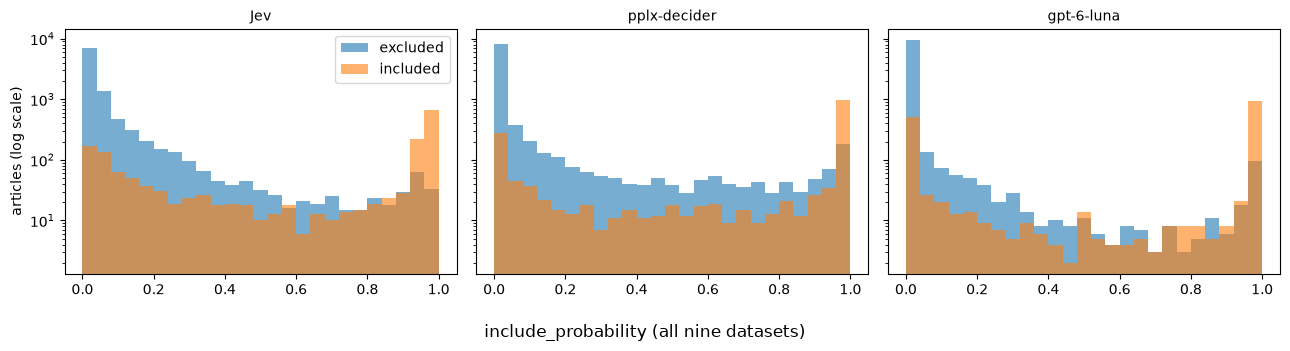

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
bins = np.linspace(0, 1, 26)
for ax, model in zip(axes, MODELS):
    df = pd.concat(data[model].values())
    ax.hist(df.loc[df["label"] == 0, "include_probability"].dropna(), bins=bins, alpha=0.6, label="excluded", log=True)
    ax.hist(df.loc[df["label"] == 1, "include_probability"].dropna(), bins=bins, alpha=0.6, label="included", log=True)
    ax.set_title(model, fontsize=10)
axes[0].legend()
axes[0].set_ylabel("articles (log scale)")
fig.supxlabel("include_probability (all nine datasets)")
plt.tight_layout()
plt.show()

## Hybrid: decision model first, LLM only for uncertain articles

As in `decision_evaluation.ipynb`: articles with 0.1 <= p < 0.9 (or a refused include question) take the stored v1 LLM
decision (`llm_score >= 3`); the rest keep the decision model's (`p >= 0.5`). The LLM cost is estimated at $0.0001 per
article, the measured cost of `TitleAbstractReviewer` with `gpt-6-luna`.

In [14]:
LLM_COST_PER_ITEM = 0.0001
rows = []
for model in MODELS:
    for name in DATASETS:
        df = data[model][name]
        p = df["include_probability"]
        uncertain = p.isna() | ((p >= 0.1) & (p < 0.9))
        decision = np.where(uncertain, df["llm_score"] >= 3, p >= 0.5)
        recall, precision, _ = recall_precision(df["label"], decision)
        model_cost = runs[model][name]["cost"] / runs[model][name]["items"]
        cost = 1000 * (model_cost + uncertain.mean() * LLM_COST_PER_ITEM)
        rows.append({"model": model, "dataset": name, "routed_to_llm": uncertain.mean(), "recall": recall, "precision": precision, "cost_per_1k": cost})
hybrid = pd.DataFrame(rows)
llm_rows = [recall_precision(data["Jev"][name]["label"], data["Jev"][name]["llm_score"] >= 3) for name in DATASETS]
summary = hybrid.groupby("model", sort=False)[["routed_to_llm", "recall", "precision", "cost_per_1k"]].mean()
summary.loc["LLM only"] = [1.0, np.mean([r[0] for r in llm_rows]), np.mean([r[1] for r in llm_rows]), 1000 * LLM_COST_PER_ITEM]
summary.round(4)

,routed_to_llm,recall,precision,cost_per_1k
model,,,,
Jev,0.1878,0.5934,0.3727,0.0781
pplx-decider,0.1325,0.6182,0.4451,0.0672
gpt-6-luna,0.0560,0.4873,0.4676,0.1652
LLM only,1.0000,0.6081,0.3728,0.1000


## Summary

In [15]:
summary = pd.DataFrame(
    {
        "mean AUC": auc_table.loc["mean", COLUMNS],
        "mean WSS@95": wss_table.loc["mean", COLUMNS],
        "cost per 1k articles ($)": list(totals["cost_per_1k_articles"]) + [1000 * LLM_COST_PER_ITEM],
        "datasets won (AUC)": [int((auc_table.drop("mean")[COLUMNS].idxmax(axis=1) == column).sum()) for column in COLUMNS],
    }
)
summary.round(3)

,mean AUC,mean WSS@95,cost per 1k articles ($),datasets won (AUC)
Jev,0.878,0.383,0.059,1
pplx-decider,0.895,0.510,0.052,7
gpt-6-luna,0.779,0.123,0.159,1
LLM,0.828,0.223,0.100,0
